<a href="https://colab.research.google.com/github/Jgour5454/Brain-Tumor-Detection-DL/blob/main/Hybrid_VGG16_and_19_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive


Processing val: 100%|██████████| 613/613 [00:03<00:00, 164.86it/s]

Found 2451 images belonging to 3 classes.
Found 613 images belonging to 3 classes.


🏗️ Building Hybrid VGG16 + VGG19 Model...


Model: "functional_4"

...

 Total params: 35,395,971 (135.02 MB)

 Trainable params: 656,899 (2.51 MB)

 Non-trainable params: 34,739,072 (132.52 MB)

🚀 Training Hybrid Model on T4 GPU...
Epoch 1/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 86s 865ms/step - accuracy: 0.4957 - loss: 1.0421 - val_accuracy: 0.5710 - val_loss: 0.9368
Epoch 2/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 49s 635ms/step - accuracy: 0.6271 - loss: 0.8685 - val_accuracy: 0.6917 - val_loss: 0.7747
Epoch 3/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 49s 634ms/step - accuracy: 0.6899 - loss: 0.7359 - val_accuracy: 0.7259 - val_loss: 0.6668
Epoch 4/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 49s 638ms/step - accuracy: 0.7348 - loss: 0.6384 - val_accuracy: 0.7586 - val_loss: 0.5815
Epoch 5/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 82s 640ms/step - accuracy: 0.7825 - loss: 0.5481 - val_accuracy: 0.7847 - val_loss: 0.5242
Epoch 6/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 49s 630ms/step - accuracy: 0.7948 - loss: 0.5054 - val_accuracy: 0.8091 - val_loss: 0.5174
Epoch 7/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 49s 630ms/step - accuracy: 0.8115 - loss: 0.4617 - val_accuracy: 0.8042 - val_loss: 0.4536
Epoch 8/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 49s 636ms/step - accur


      HYBRID VGG16+VGG19 PERFORMANCE
Accuracy : 88.74%
Kappa    : 0.8263
MCC      : 0.8296

Report:
               precision    recall  f1-score   support

  meningioma       0.96      0.84      0.90       292
      glioma       0.77      0.88      0.82       150
   pituitary       0.90      0.97      0.94       171

    accuracy                           0.89       613
   macro avg       0.88      0.90      0.88       613
weighted avg       0.90      0.89      0.89       613



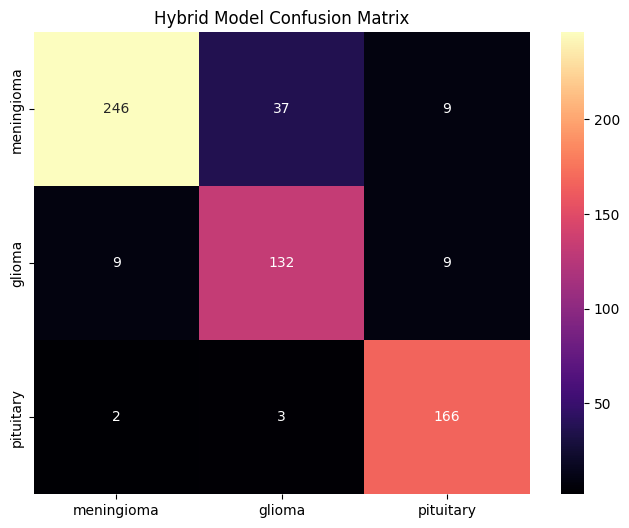

In [ ]:
# ==============================================================================
# 1. SETUP & DATA PREPARATION
# ==============================================================================
import os, zipfile, scipy.io, cv2, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, cohen_kappa_score, matthews_corrcoef
from google.colab import drive

import tensorflow as tf
from tensorflow.keras.applications import VGG16, VGG19
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Concatenate, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Mount Drive
drive.mount('/content/drive', force_remount=True)

# Paths
ZIP_PATH   = '/content/drive/MyDrive/ML/1512427.zip'
MAT_DIR    = '/content/all_mats'
BASE_DATA_DIR = '/content/hybrid_vgg_data'
TRAIN_DIR  = os.path.join(BASE_DATA_DIR, 'train')
VAL_DIR    = os.path.join(BASE_DATA_DIR, 'val')

# Extraction Logic
if not os.path.exists(MAT_DIR):
    print("📦 Extracting Dataset...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall('/content/raw')
    os.makedirs(MAT_DIR, exist_ok=True)
    for nz in [f for f in os.listdir('/content/raw') if f.endswith('.zip')]:
        with zipfile.ZipFile(os.path.join('/content/raw', nz), 'r') as z:
            z.extractall(MAT_DIR)

categories = ['meningioma', 'glioma', 'pituitary']
for cat in categories:
    os.makedirs(os.path.join(TRAIN_DIR, cat), exist_ok=True)
    os.makedirs(os.path.join(VAL_DIR, cat), exist_ok=True)

mat_files = [f for f in os.listdir(MAT_DIR) if f.endswith('.mat')]
train_files, val_files = train_test_split(mat_files, test_size=0.2, random_state=42)

def convert_to_disk(file_list, target_dir):
    for fname in tqdm(file_list, desc=f"Processing {target_dir.split('/')[-1]}"):
        try:
            try:
                m   = scipy.io.loadmat(os.path.join(MAT_DIR, fname))['cjdata'][0][0]
                lbl = int(m[0][0][0]) - 1
                img = m[2].astype(np.float32)
            except:
                import h5py
                with h5py.File(os.path.join(MAT_DIR, fname), 'r') as f:
                    lbl = int(f['cjdata']['label'][0][0]) - 1
                    img = np.array(f['cjdata']['image']).T

            img     = ((img - img.min()) / (img.max() - img.min()) * 255).astype(np.uint8)
            img     = cv2.resize(img, (224, 224))
            img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
            cv2.imwrite(os.path.join(target_dir, categories[lbl], fname.replace('.mat', '.jpg')), img_rgb)
        except:
            continue

convert_to_disk(train_files, TRAIN_DIR)
convert_to_disk(val_files,   VAL_DIR)

# ==============================================================================
# 2. DATA GENERATORS
# ==============================================================================
train_datagen = ImageDataGenerator(rescale=1./255, horizontal_flip=True, rotation_range=15)
val_datagen   = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(TRAIN_DIR, target_size=(224,224), batch_size=32, class_mode='categorical')
val_gen   = val_datagen.flow_from_directory(VAL_DIR,   target_size=(224,224), batch_size=32, class_mode='categorical', shuffle=False)

# ==============================================================================
# 3. HYBRID MODEL  ✅ FIXED — shared Input passed via functional call
# ==============================================================================
print("🏗️ Building Hybrid VGG16 + VGG19 Model...")

# ── Step 1: Load both base models WITHOUT input_tensor ─────────────────────────
vgg16_base = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
vgg19_base = VGG19(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# ── Step 2: Rename every layer to avoid name collisions ───────────────────────
for layer in vgg16_base.layers:
    layer._name = f"vgg16_{layer.name}"

for layer in vgg19_base.layers:
    layer._name = f"vgg19_{layer.name}"

# ── Step 3: Freeze all pretrained weights ─────────────────────────────────────
vgg16_base.trainable = False
vgg19_base.trainable = False

# ── Step 4: Create ONE shared Input, pass it through both bases ───────────────
img_input = Input(shape=(224, 224, 3), name="main_input")

vgg16_out = vgg16_base(img_input)   # ✅ functional call — no graph conflict
vgg19_out = vgg19_base(img_input)   # ✅ functional call — no graph conflict

# ── Step 5: Pooling ───────────────────────────────────────────────────────────
x16 = GlobalAveragePooling2D(name="gap_v16")(vgg16_out)
x19 = GlobalAveragePooling2D(name="gap_v19")(vgg19_out)

# ── Step 6: Fusion & Classifier ───────────────────────────────────────────────
merged = Concatenate(name="fusion_layer")([x16, x19])
x      = Dense(512, activation='relu', name="fc1")(merged)
x      = Dropout(0.5, name="dropout")(x)
x      = Dense(256, activation='relu', name="fc2")(x)
output = Dense(3,   activation='softmax', name="predictions")(x)

# ── Step 7: Assemble & Compile ────────────────────────────────────────────────
model = Model(inputs=img_input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()   # All layer names will be unique ✅

# ==============================================================================
# 4. TRAINING & EVALUATION
# ==============================================================================
print("🚀 Training Hybrid Model on T4 GPU...")
history = model.fit(train_gen, validation_data=val_gen, epochs=50)

print("\n📊 Calculating Final Performance Metrics...")
val_gen.reset()
preds  = model.predict(val_gen)
y_pred = np.argmax(preds, axis=1)
y_true = val_gen.classes

accuracy = np.mean(y_pred == y_true)
kappa    = cohen_kappa_score(y_true, y_pred)
mcc      = matthews_corrcoef(y_true, y_pred)

print(f"\n" + "="*45)
print(f"      HYBRID VGG16+VGG19 PERFORMANCE")
print(f"="*45)
print(f"Accuracy : {accuracy*100:.2f}%")
print(f"Kappa    : {kappa:.4f}")
print(f"MCC      : {mcc:.4f}")
print(f"\nReport:\n", classification_report(y_true, y_pred, target_names=categories))

# Save
model.save('/content/drive/MyDrive/ML/hybrid_vgg_fixed.h5')

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='magma', xticklabels=categories, yticklabels=categories)
plt.title('Hybrid Model Confusion Matrix')
plt.show()